In [1]:
import numpy as np
import pandas as pd
import os
import cv2

In [2]:
labels=os.listdir(r"C:\Users\helna\Downloads\archive\train")

In [3]:
labels

['Closed', 'no_yawn', 'Open', 'yawn']

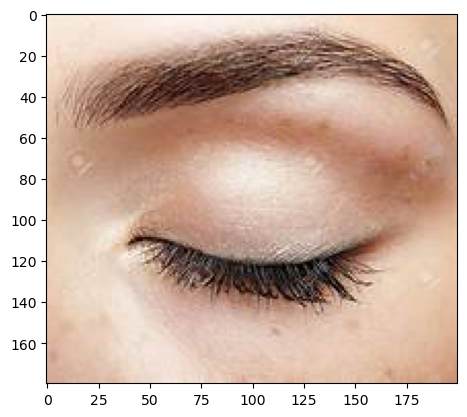

In [4]:
import matplotlib.pyplot as plt
plt.imshow(plt.imread(r"C:\Users\helna\Downloads\closed.jpeg"))

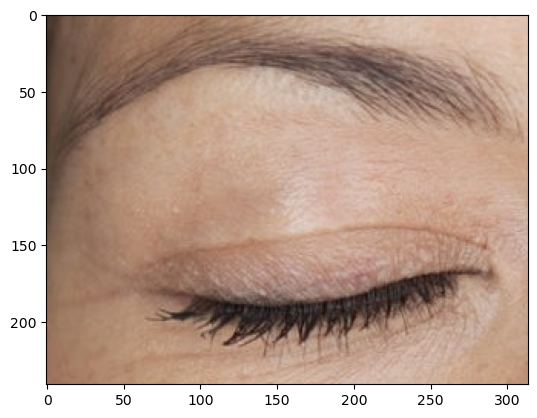

In [5]:
plt.imshow(plt.imread(r"C:\Users\helna\Downloads\archive\train\Closed\_90.jpg"))

In [6]:
a=plt.imread(r"C:\Users\helna\Downloads\archive\train\yawn\9.jpg")

In [7]:
a.shape

(480, 640, 3)

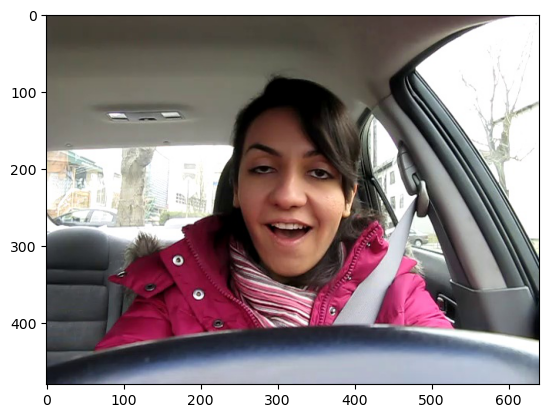

In [8]:
plt.imshow(plt.imread(r"C:\Users\helna\Downloads\archive\train\yawn\9.jpg"))

In [9]:
def face_for_yawn(direc=r"C:\Users\helna\Downloads\archive\train", face_cas_path=r"C:\Users\helna\Downloads\haarcascade_frontalface_default (1).xml"):
    yaw_no = []
    IMG_SIZE = 145
    categories = ["yawn", "no_yawn"]
    for category in categories:
        path_link = os.path.join(direc,category)
        class_num1 = categories.index(category)
        print(class_num1)
        for image in os.listdir(path_link):
            image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)
            face_cascade = cv2.CascadeClassifier(face_cas_path)
            faces = face_cascade.detectMultiScale(image_array,1.3,5)
            for (x,y,w,h) in faces:
                img = cv2.rectangle(image_array, (x,y), (x+w,y+h), (0,255,0),2)
                roi_color = img[y:y+h, x:x+w]
                resized_array=cv2.resize(roi_color, (IMG_SIZE,IMG_SIZE))
                yaw_no.append([resized_array,class_num1])
    return yaw_no

yawn_no_yawn = face_for_yawn()

         
        
    

0
1


In [10]:
def get_data(dir_path=r"C:\Users\helna\Downloads\archive\train",face_cas=r"C:\Users\helna\Downloads\haarcascade_frontalface_default (1).xml", eye_cas=r"C:\Users\helna\Downloads\haarcascade_eye.xml"):
    labels = ['Closed','Open']
    IMG_SIZE = 145
    data = []
    for label in labels:
        path = os.path.join(dir_path,label)
        class_num = labels.index(label)
        class_num +=2
        print(class_num)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path,img), cv2.IMREAD_COLOR)
                resized_array = cv2.resize(img_array,(IMG_SIZE,IMG_SIZE))
                data.append([resized_array,class_num])
            except Exception as e:
                print(e)
    return data

In [11]:
data_train=get_data()

2
3


In [12]:
def append_data():
# total_data=[]
    yaw_no = face_for_yawn()
    data = get_data()
    yaw_no.extend(data)
    return (yaw_no)

In [13]:
new_data=append_data()

0
1
2
3


In [14]:
X=[]
y=[]
for feature, label in new_data:
    X.append(feature)
    y.append(label)

In [15]:
X = np.array(X)
X=X.reshape(-1,145,145,3)

In [16]:
from sklearn.preprocessing import LabelBinarizer
label_bin=LabelBinarizer()
y=label_bin.fit_transform(y)

In [17]:
y=np.array(y)

In [18]:
from sklearn.model_selection import train_test_split
seed=42
test_size = 0.30
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=seed,test_size=test_size)

In [19]:
len(X_test)

578

In [20]:
!pip install tensorflow

In [21]:
pip uninstall --yes tensorflow tensorflow-estimator keras


Found existing installation: tensorflow 2.13.0
Uninstalling tensorflow-2.13.0:
  Successfully uninstalled tensorflow-2.13.0
Found existing installation: tensorflow-estimator 2.13.0
Uninstalling tensorflow-estimator-2.13.0:
  Successfully uninstalled tensorflow-estimator-2.13.0
Found existing installation: keras 2.13.1
Uninstalling keras-2.13.1:
  Successfully uninstalled keras-2.13.1
Note: you may need to restart the kernel to use updated packages.


In [22]:
pip cache purge


Files removed: 52
Note: you may need to restart the kernel to use updated packages.


In [23]:
pip install tensorflow-cpu


     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------- ------------------ 30.7/60.8 kB 330.3 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/60.8 kB 375.8 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 404.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -- ------------------------------------- 0.1/1.4 MB 2.3 MB/s eta 0:00:01
   -- ------------------------------------- 0.1/1.4 MB 1.3 MB/s eta 0:00:01
   ----- ---------------------------------- 0.2/1.4 MB 1.3 MB/s eta 0:00:01
   ------- -------------------------------- 0.3/1.4 MB 1.4 MB/s eta 0:00:01
   ---------- ----------------------------- 0.4/1.4 MB 1.6 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.4 MB 1.8 MB/s eta 0:00:01
   ---------------- ----------------------- 0.6/1.4 MB 1.8 MB/s eta 0:00:01
   -----------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tensorflow-intel 2.13.0 requires tensorflow-estimator<2.14,>=2.13.0, which is not installed.
astropy 5.3.4 requires numpy<2,>=1.21, but you have numpy 2.1.3 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.1.3 which is incompatible.
matplotlib 3.8.0 requires numpy<2,>=1.21, but you have numpy 2.1.3 which is incompatible.
numba 0.59.0 requires numpy<1.27,>=1.22, but you have numpy 2.1.3 which is incompatible.
pandas 2.1.4 requires numpy<2,>=1.23.2; python_version == "3.11", but you have numpy 2.1.3 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.1.3 which is incompatible.
scipy 1.11.4 requires numpy<1.2

In [24]:
pip install tensorflow==2.13.0

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
    --------------------------------------- 0.0/1.7 MB 435.7 kB/s eta 0:00:04
    --------------------------------------- 0.0/1.7 MB 435.7 kB/s eta 0:00:04
    --------------------------------------- 0.0/1.7 MB 435.7 kB/s eta 0:00:04
   -- ------------------------------------- 0.1/1.7 MB 403.5 kB/s eta 0:00:04
   -- ------------------------------------- 0.1/1.7 MB 403.5 kB/s eta 0:00:04
   -- ------------------------------------- 0.1/1.7 MB 403.5 kB/s eta 0:00:04
   -- ------------------------------------- 0.1/1.7 MB 403.5 kB/s eta 0:00:04
   ---- ----------------------------------- 0.2/1.7 MB 479.2 kB/s eta 0:00:04
   ---- ----------------------------------- 0.2/1.7 MB 479.2 kB/s eta 0:00:04
   ---- ----------------------------------- 0.2/1.7 MB 479.2 kB/s eta 0:00:04
   ---- ----------------------------------- 0.2/1.7 MB 479.2 kB/s eta 0:00:04
   -

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
optree 0.16.0 requires typing-extensions>=4.6.0, but you have typing-extensions 4.5.0 which is incompatible.
sqlalchemy 2.0.25 requires typing-extensions>=4.6.0, but you have typing-extensions 4.5.0 which is incompatible.
tensorflow-cpu 2.19.0 requires keras>=3.5.0, but you have keras 2.13.1 which is incompatible.
tensorflow-cpu 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 1.24.3 which is incompatible.
tensorflow-cpu 2.19.0 requires tensorboard~=2.19.0, but you have tensorboard 2.13.0 which is incompatible.


In [25]:
import tensorflow as tf
print(tf.__version__)


2.13.0


In [26]:

from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

In [27]:
train_generator = ImageDataGenerator(rescale=1/255, zoom_range=0.2, horizontal_flip=True, rotation_range=30)
test_generator = ImageDataGenerator(rescale=1/255)

#train_generator=tf.data.Dataset.from_tensor_slices((X_train,y_train))
#test_generator=tf.data.Dataset.from_tensor_slices((X_test,y_test))

train_generator=train_generator.flow(np.array(X_train), y_train, shuffle=False)
test_generator = test_generator.flow(np.array(X_test), y_test, shuffle=False)

In [28]:
model = Sequential()
model.add(Conv2D(256, (3,3), activation="relu", input_shape=(145,145,3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3), activation="relu"))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(32,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(64, activation="relu"))
model.add(Dense(4,activation="softmax"))
model.compile(loss="categorical_crossentropy",metrics=["accuracy"],optimizer="adam")
model.summary()
          
          

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 143, 143, 256)     7168      
                                                                 
 max_pooling2d (MaxPooling2  (None, 71, 71, 256)       0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 69, 69, 128)       295040    
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 34, 34, 128)       0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 64)        73792     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 64)        0

In [29]:
history=model.fit(train_generator,epochs=50,validation_data=test_generator, shuffle=True, validation_steps=len(test_generator))

Epoch 1/50
43/43 [==============================] - 699s 16s/step - loss: 0.9569 - accuracy: 0.5843 - val_loss: 0.5454 - val_accuracy: 0.7837
Epoch 2/50
43/43 [==============================] - 435s 10s/step - loss: 0.5188 - accuracy: 0.7676 - val_loss: 0.3687 - val_accuracy: 0.8633
Epoch 3/50
43/43 [==============================] - 392s 9s/step - loss: 0.3897 - accuracy: 0.8352 - val_loss: 0.3092 - val_accuracy: 0.8806
Epoch 4/50
43/43 [==============================] - 393s 9s/step - loss: 0.3418 - accuracy: 0.8597 - val_loss: 0.3293 - val_accuracy: 0.8685
Epoch 5/50
43/43 [==============================] - 252s 6s/step - loss: 0.2845 - accuracy: 0.8738 - val_loss: 0.3338 - val_accuracy: 0.8668
Epoch 6/50
43/43 [==============================] - 196s 5s/step - loss: 0.2708 - accuracy: 0.8924 - val_loss: 0.2177 - val_accuracy: 0.9083
Epoch 7/50
43/43 [==============================] - 201s 5s/step - loss: 0.2380 - accuracy: 0.9027 - val_loss: 0.1930 - val_accuracy: 0.9152
Epoch 8/50


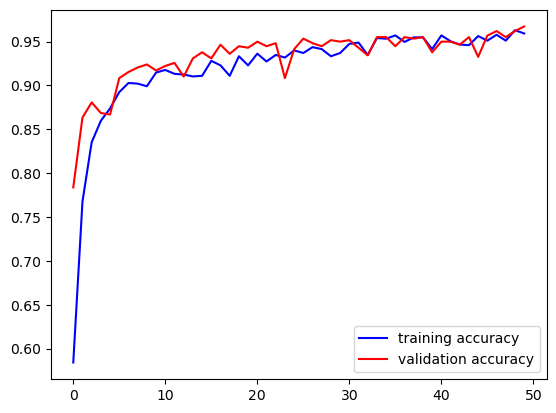

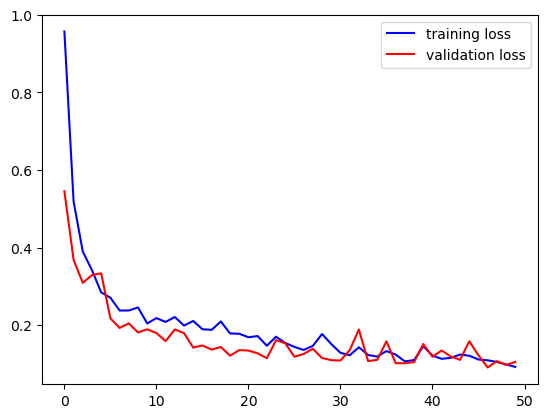

In [30]:
accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(len(accuracy))

plt.plot(epochs,accuracy,"b",label="training accuracy")
plt.plot(epochs,val_accuracy,"r",label="validation accuracy")
plt.legend()
plt.show()

plt.plot(epochs,loss,"b", label="training loss")
plt.plot(epochs,val_loss,"r",label="validation loss")
plt.legend()
plt.show()

In [31]:
model.save("drowiness_new7.h5")

C:\Users\helna\anaconda3\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [32]:
model.save("drowiness_new7.model")

INFO:tensorflow:Assets written to: drowiness_new7.model\assets


INFO:tensorflow:Assets written to: drowiness_new7.model\assets


In [34]:
# Get class predictions
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)


19/19 [==============================] - 21s 1s/step


In [37]:
predictions

array([[0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]], dtype=float32)

In [38]:
labels_new = ["yawn", "no_yawn", "Closed", "Open"]

In [40]:
from sklearn.metrics import classification_report
print(classification_report(np.argmax(y_test, axis=1), predictions, target_names=labels_new))

ValueError: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets

In [41]:
from sklearn.metrics import classification_report
import numpy as np

# Convert one-hot predictions to class labels
y_pred_classes = np.argmax(predictions, axis=1)

# Convert y_test to class labels if it's also one-hot encoded
y_true_classes = np.argmax(y_test, axis=1)

# Now use classification_report with class indices
print(classification_report(y_true_classes, y_pred_classes, target_names=labels_new))


              precision    recall  f1-score   support

        yawn       0.76      0.90      0.83        63
     no_yawn       0.87      0.74      0.80        74
      Closed       0.94      0.99      0.96       215
        Open       0.99      0.93      0.96       226

    accuracy                           0.93       578
   macro avg       0.89      0.89      0.89       578
weighted avg       0.93      0.93      0.93       578



In [63]:
labels_new = ["yawn", "no_yawn", "Closed", "Open"]
IMG_SIZE = 145
def prepare(filepath, face_cas=r"C:\Users\helna\Downloads\haarcascade_frontalface_default (1).xml"):
    img_array = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img_array = img_array / 255
    resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
    return resized_array.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

model = tf.keras.models.load_model(r"C:\Users\helna\delna\delna\New folder\drowiness_new7.h5")

In [68]:
print("Raw prediction:", prediction)
print("Predicted class:", np.argmax(prediction))


Raw prediction: [[7.76480926e-16 1.02289105e-14 9.96150732e-01 3.84931429e-03]]
Predicted class: 2


In [64]:

prediction = model.predict([prepare(r"C:\Users\helna\Downloads\archive\train\no_yawn\931.jpg")])
np.argmax(prediction)


1/1 [==============================] - 0s 174ms/step


2

In [65]:
predictions = model.predict([prepare(r"C:\Users\helna\Downloads\archive\train\Closed\_75.jpg")])
np.argmax(predictions)

1/1 [==============================] - 0s 63ms/step


2

In [66]:
predictions = model.predict([prepare(r"C:\Users\helna\Downloads\archive\train\Open\_95.jpg")])
np.argmax(predictions)


1/1 [==============================] - 0s 83ms/step


3

In [67]:
prediction = model.predict([prepare(r"C:\Users\helna\Downloads\archive\train\yawn\89.jpg")])
np.argmax(prediction)

1/1 [==============================] - 0s 77ms/step


2